In [1]:
import matplotlib.pyplot as plt
from sklearn import pipeline
from rdkit import Chem
import seaborn as sns
import pandas as pd
import numpy as np
import sklearn
import scipy

In [2]:
def get_high_corr(X):
    corr_matrix = X.corr().abs()

    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    return (
        upper.unstack()
        .dropna()
        .sort_values(ascending=False)
    )

In [3]:
df = pd.read_csv("../data/processed_dataset_rerun.csv")

In [26]:
df["num_atoms"] = df.smiles.apply(lambda x : Chem.MolFromSmiles(x).GetNumHeavyAtoms())

(-13.0, 13.0)

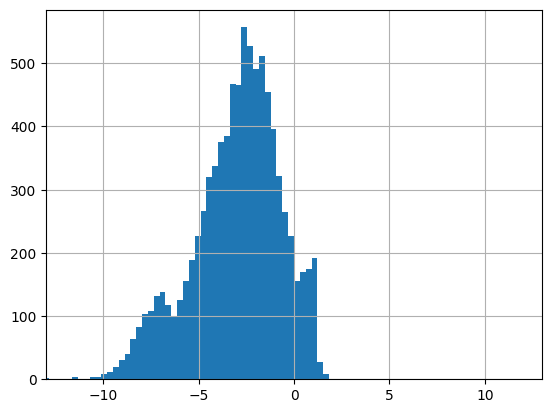

In [27]:
df["solubility"].hist(bins=50)
plt.xlim(-13, 13)

In [4]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [5]:
from ml_enhance import get_topology_features

X.columns[~X.columns.isin(get_topology_features())]

Index(['atomization_energy', 'homo_lumo_gap', 'ionization_energy',
       'electron_affinity', 'chemical_potential', 'molecular_dipole_norm',
       'molecular_quadrupole_principal_invariant_2',
       'molecular_quadrupole_principal_invariant_3',
       'molecular_polarizability_mean', 'molecular_polarizability_anisotropy',
       ...
       'std_atomic_charge_dipole_interaction',
       'avg_atomic_charge_quadrupole_interaction',
       'min_atomic_charge_quadrupole_interaction',
       'max_atomic_charge_quadrupole_interaction',
       'std_atomic_charge_quadrupole_interaction',
       'avg_atomic_dipole_dipole_interaction',
       'min_atomic_dipole_dipole_interaction',
       'max_atomic_dipole_dipole_interaction',
       'std_atomic_dipole_dipole_interaction', 'num_heavy_H_bonds'],
      dtype='str', length=133)

In [5]:
corr = X.corr().abs()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
)

high_corr = high_corr[high_corr > 0.6]

high_corr.sort_values(ascending=False).head(50)

NumAmideBonds                         fr_amide                                1.000000
fr_Ar_NH                              fr_Nhpyrrole                            1.000000
min_partial_charge_water              min_partial_charge_dmso                 1.000000
std_partial_charge_water              std_partial_charge_dmso                 1.000000
max_partial_charge_water              max_partial_charge_dmso                 0.999998
MaxAbsEStateIndex                     MaxEStateIndex                          0.999997
solvation_energy_water                solvation_energy_dmso                   0.999996
MolWt                                 ExactMolWt                              0.999987
min_partial_charge_thf                min_partial_charge_dmso                 0.999970
min_partial_charge_water              min_partial_charge_thf                  0.999965
std_partial_charge_thf                std_partial_charge_dmso                 0.999958
std_partial_charge_water              std_p

In [12]:
high_corr.filter(regex="ir_mode_count_2750").sort_values(ascending=False).head(50)

ir_mode_count_2750_4000       num_heavy_H_bonds          0.999890
gibbs_free_energy_300K        ir_mode_count_2750_4000    0.989197
zero_point_energy             ir_mode_count_2750_4000    0.983909
ir_mode_count_1500            ir_mode_count_2750_4000    0.919564
ir_mode_count_2750_4000       SMR_VSA5                   0.910895
                              SlogP_VSA5                 0.888358
atomization_energy            ir_mode_count_2750_4000    0.887273
ir_mode_count_2750_4000       Chi1n                      0.881860
                              Chi2n                      0.860080
                              Chi0n                      0.856146
                              Kappa2                     0.852318
molecular_volume              ir_mode_count_2750_4000    0.851384
molecular_sasa                ir_mode_count_2750_4000    0.833933
ir_mode_count_2750_4000       Phi                        0.819357
                              Kappa1                     0.818924
          

In [6]:
high_corr.filter(regex="MolWt").sort_values(ascending=False).head(50)

MolWt                          ExactMolWt             0.999987
                               HeavyAtomMolWt         0.997226
HeavyAtomMolWt                 ExactMolWt             0.997004
ExactMolWt                     LabuteASA              0.974387
MolWt                          LabuteASA              0.973767
ExactMolWt                     Chi0v                  0.964517
MolWt                          Chi0v                  0.963891
HeavyAtomMolWt                 LabuteASA              0.959927
ExactMolWt                     Chi0                   0.952163
MolWt                          Chi0                   0.950977
ExactMolWt                     HeavyAtomCount         0.947578
                               MolMR                  0.946795
MolWt                          HeavyAtomCount         0.946364
                               MolMR                  0.946007
ExactMolWt                     NumValenceElectrons    0.945093
MolWt                          NumValenceElectrons    0

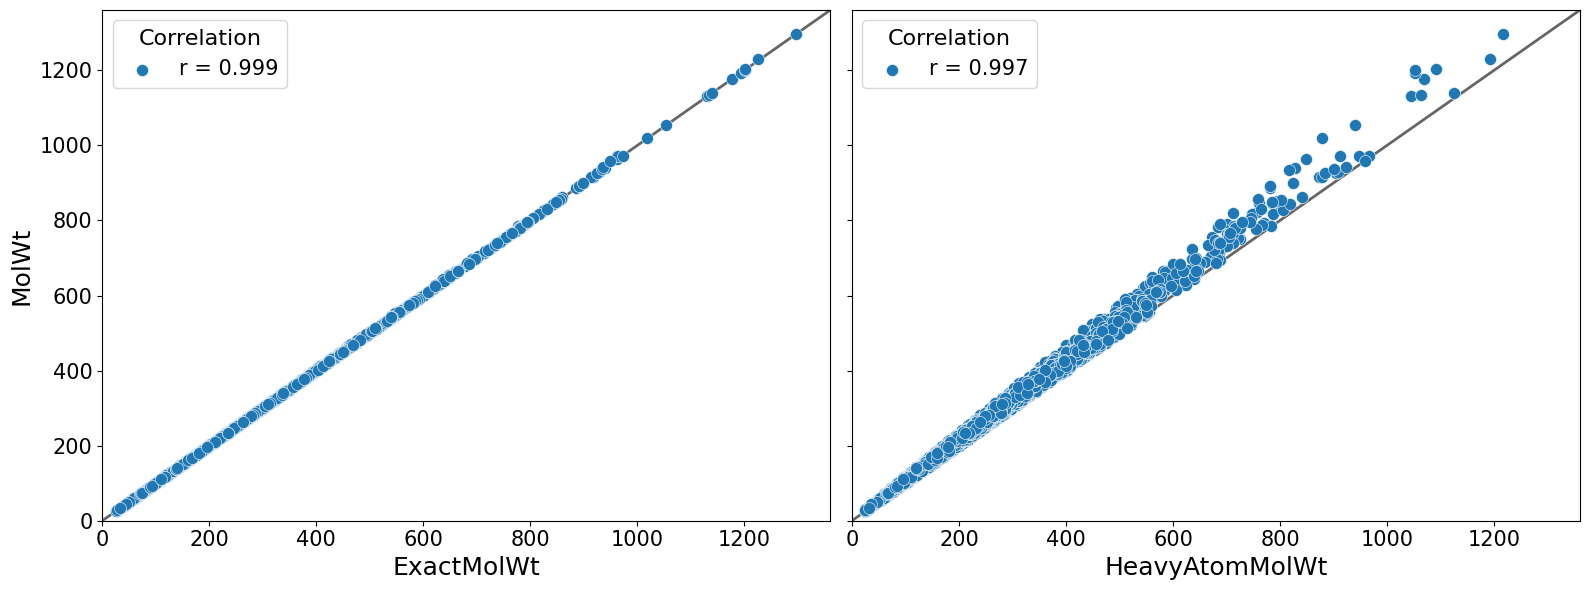

In [ ]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    sharey=True
)

scatter_kws = dict(
    s=75,
    alpha=1,
    edgecolor="white",
    linewidth=0.4
)

plots = [
    ("ExactMolWt", "r = 0.999"),
    ("HeavyAtomMolWt", "r = 0.997")
]

for ax, (feature, corr) in zip(axes, plots):

    # scatterplot
    sns.scatterplot(
        data=X,
        x=feature,
        y="MolWt",
        ax=ax,
        label=corr,
        zorder=2,
        **scatter_kws
    )

    # perfect-correlation diagonal
    min_val = min(X[feature].min(), X["MolWt"].min())
    max_val = max(X[feature].max(), X["MolWt"].max())

    padding = 0.05 * (max_val - min_val)

    line_min = min_val - padding if min_val - padding > 0 else 0
    line_max = max_val + padding

    ax.set_xlim(line_min, line_max)
    ax.set_ylim(line_min, line_max)

    ax.plot(
        [line_min, line_max],
        [line_min, line_max],
        color="black",
        alpha=0.6,
        linewidth=2,
        zorder=1
    )

    ax.set_xlabel(feature, fontsize=18)
    ax.tick_params(axis='both', labelsize=15)


    # legend
    ax.legend(
        loc="upper left",
        title="Correlation",
        fontsize=15,
        title_fontsize=16,
        frameon=True
    )

axes[0].set_ylabel("MolWt", fontsize=18)
plt.tight_layout()
# plt.savefig("MolWtcorr.pdf", format="pdf")
plt.show()

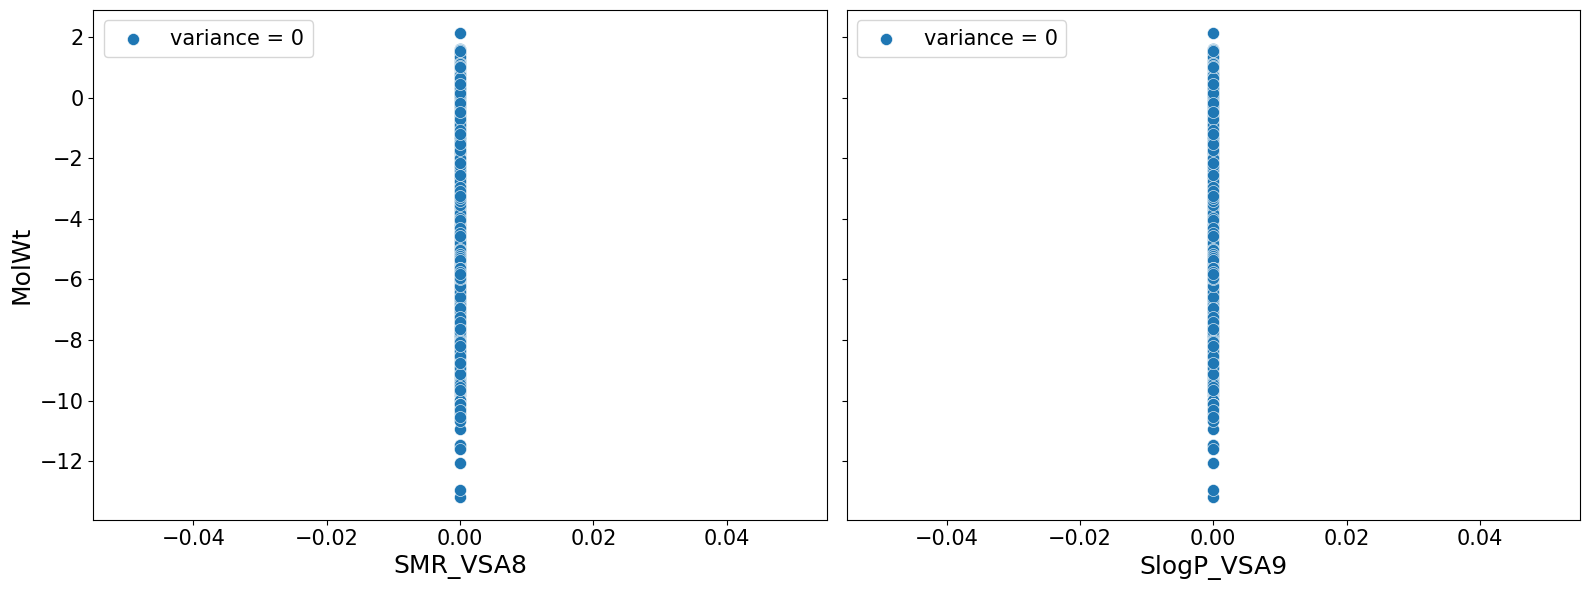

In [ ]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    sharey=True
)

scatter_kws = dict(
    s=75,
    alpha=1,
    edgecolor="white",
    linewidth=0.4
)

plots = [
    ("SMR_VSA8", "variance = 0"),
    ("SlogP_VSA9", "variance = 0")
]

for ax, (feature, corr) in zip(axes, plots):

    # scatterplot
    sns.scatterplot(
        data=df,
        x=feature,
        y="solubility",
        ax=ax,
        label=corr,
        zorder=2,
        **scatter_kws
    )

    ax.set_xlabel(feature, fontsize=18)
    ax.tick_params(axis='both', labelsize=15)


    # legend
    ax.legend(
        loc="upper left",
        fontsize=15,
        title_fontsize=16,
        frameon=True
    )

axes[0].set_ylabel("MolWt", fontsize=18)
plt.tight_layout()
# plt.savefig("zero_var.pdf", format="pdf")
plt.show()

In [ ]:
"SMR_VSA8", "SlogP_VSA9"

In [13]:
high_corr.filter(regex="TPSA").sort_values(ascending=False).head(50)

TPSA        NOCount           0.957932
            NumHAcceptors     0.874666
            NumHeteroatoms    0.802130
            EState_VSA1       0.745381
            EState_VSA10      0.739170
            NumHDonors        0.730477
            NHOHCount         0.724453
SMR_VSA1    TPSA              0.720261
SlogP_VSA2  TPSA              0.701808
PEOE_VSA1   TPSA              0.677018
TPSA        VSA_EState3       0.634466
            VSA_EState2       0.629148
dtype: float64

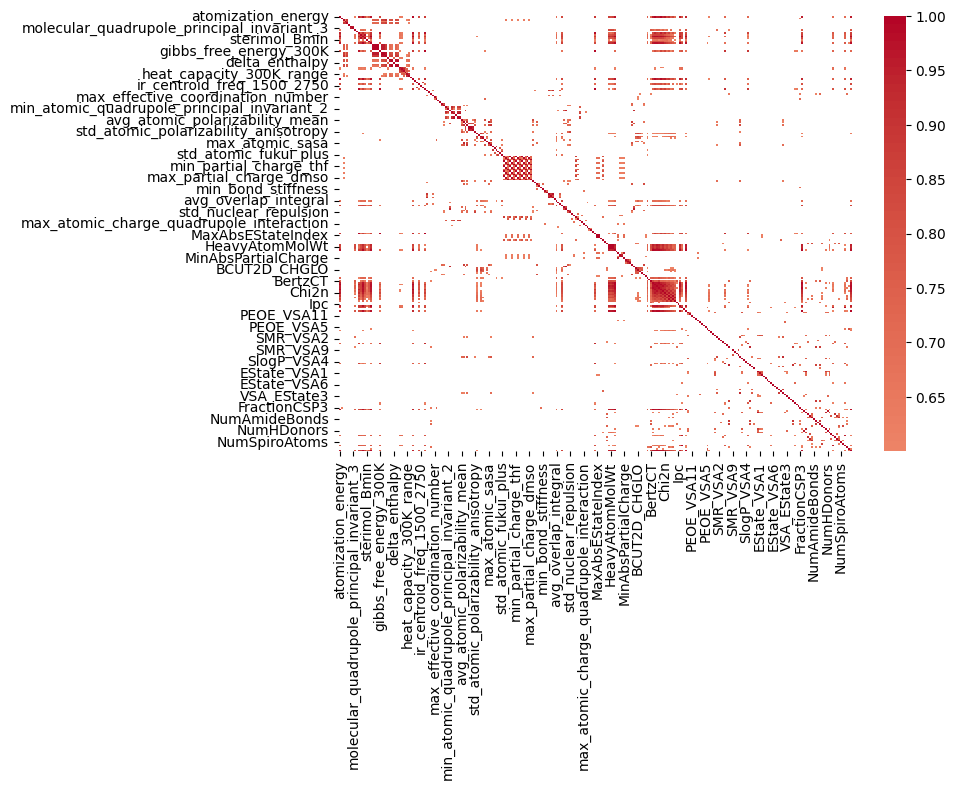

In [60]:
# Correlation matrix
corr = X.filter(regex="^(?!fr_)").corr().abs()

threshold = 0.6

# Keep only strong correlations
corr_filtered = corr.where(corr > threshold)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_filtered,
    # corr,
    cmap="coolwarm",
    center=0,
)

plt.tight_layout()
plt.show()

<Axes: xlabel='min_bond_length', ylabel='max_bond_stiffness'>

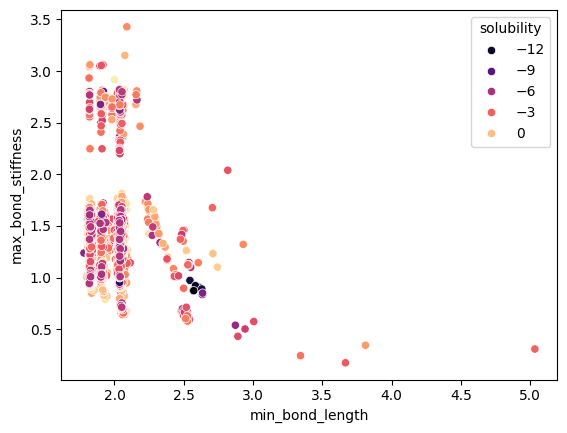

In [9]:
sns.scatterplot(data=df, x="min_bond_length", y="max_bond_stiffness", hue="solubility", palette="magma")
# plt.xscale("log")
# plt.yscale("log")

In [38]:
X.corrwith(X["molecular_dipole_norm"]).abs().sort_values(ascending=False).head(50) #.filter(regex="TPSA")

molecular_dipole_norm                         1.000000
NOCount                                       0.517025
TPSA                                          0.502340
max_partial_charge_water                      0.488820
max_partial_charge_dmso                       0.488313
max_partial_charge_thf                        0.482074
max_atomic_charge_dipole_interaction          0.475712
NumHeteroatoms                                0.471186
NumHAcceptors                                 0.467403
max_partial_charge_cyclohexane                0.466408
solvation_energy_water                        0.451761
max_partial_charge                            0.451703
solvation_energy_dmso                         0.451416
MaxEStateIndex                                0.450956
MaxAbsEStateIndex                             0.450916
solvation_energy_thf                          0.446607
solvation_energy_cyclohexane                  0.431072
EState_VSA10                                  0.418810
min_partia

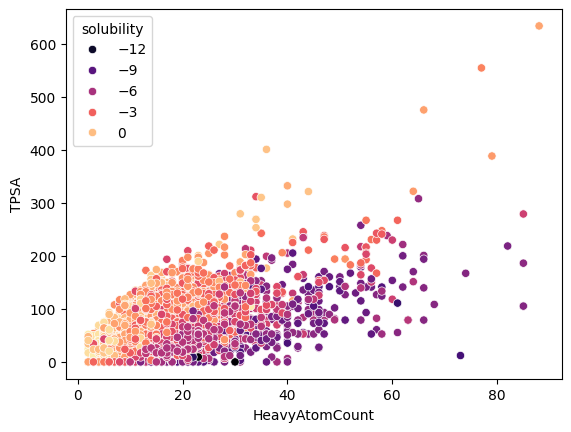

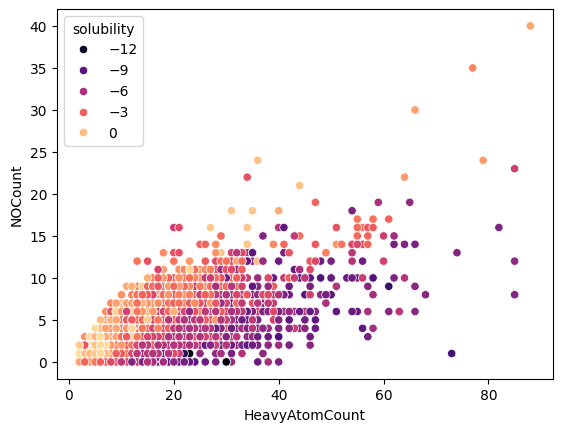

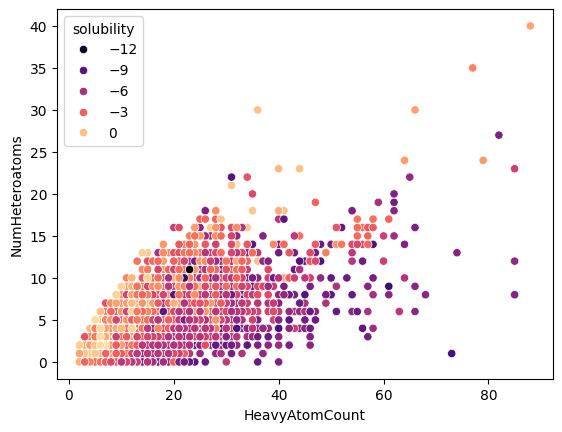

In [68]:
sns.scatterplot(data=df, x="HeavyAtomCount", y="TPSA", hue="solubility", palette="magma")
plt.show()
sns.scatterplot(data=df, x="HeavyAtomCount", y="NOCount", hue="solubility", palette="magma")
plt.show()

sns.scatterplot(data=df, x="HeavyAtomCount", y="NumHeteroatoms", hue="solubility", palette="magma")
plt.show()

# plt.xscale("log")
# plt.yscale("log")

<Axes: xlabel='HeavyAtomCount', ylabel='Phi'>

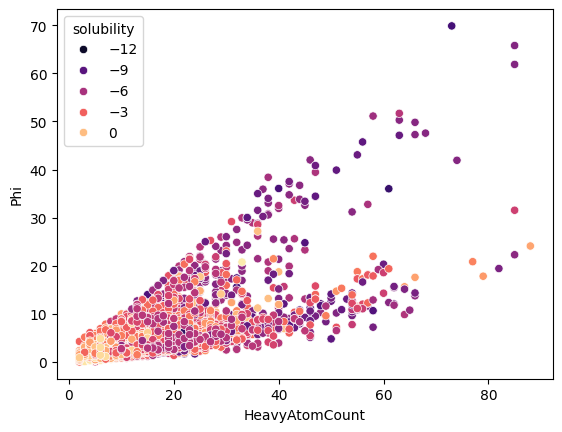

In [57]:
sns.scatterplot(data=df, x="HeavyAtomCount", y="Phi", hue="solubility", palette="magma")
# plt.xscale("log")
# plt.yscale("log")

<Axes: xlabel='HeavyAtomCount', ylabel='molecular_polarizability_mean'>

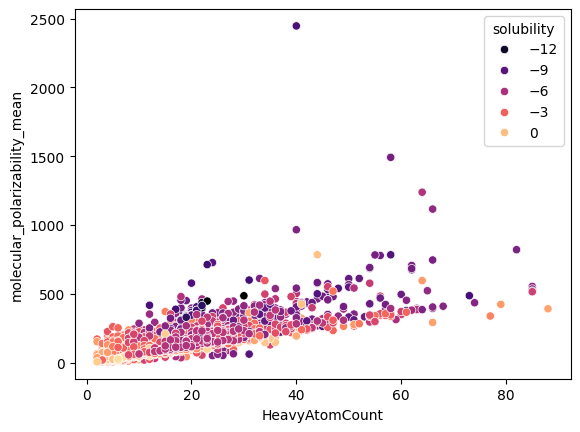

In [63]:
sns.scatterplot(data=df, x="HeavyAtomCount", y=df["molecular_polarizability_mean"].apply(abs), hue="solubility", palette="magma")
# plt.xscale("log")
# plt.yscale("log")

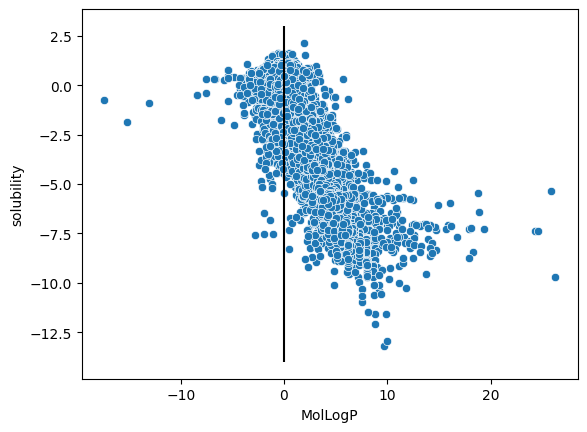

In [14]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_even_more_qm2_relevant.csv")
# sns.scatterplot(data=df, x="n_atoms", y=df["Phi"] / df["n_atoms"], hue="solubility", palette="magma")
sns.scatterplot(data=df, x="MolLogP", y="solubility") #, palette="magma")
plt.vlines(x=0, ymin=-14, ymax=3, color="black")

<Axes: xlabel='HeavyAtomCount', ylabel='MolWt'>

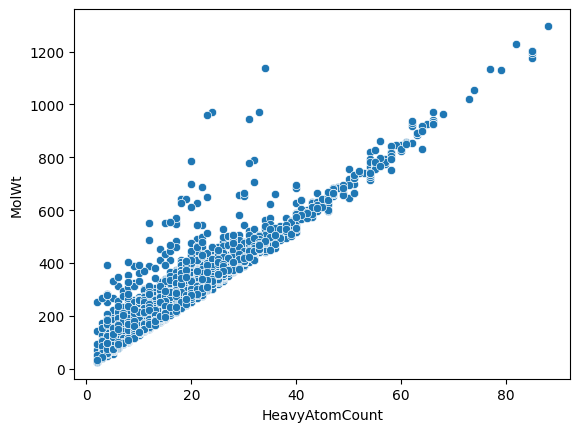

In [ ]:
sns.scatterplot(data=df, x="HeavyAtomCount", y="MolWt") #, palette="magma")
# plt.vlines(x=0, ymin=-14, ymax=3, color="black")

<Axes: xlabel='HeavyAtomCount', ylabel='solubility'>

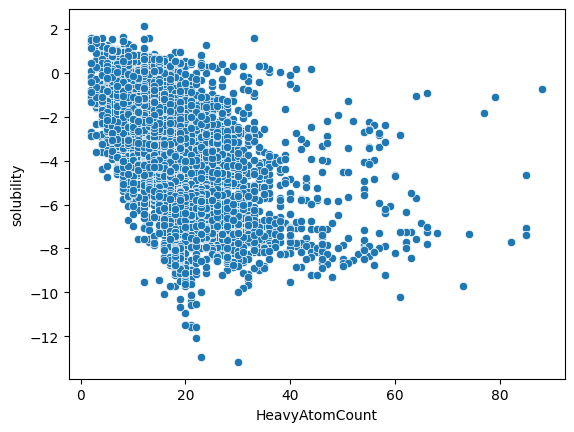

In [70]:
sns.scatterplot(data=df, x="HeavyAtomCount", y="solubility") #, palette="magma")
# plt.vlines(x=0, ymin=-14, ymax=3, color="black")

In [94]:
test = pd.concat([df.filter(regex="Num|Hall|RingCount|SlogP|MolLogP"), df["n_atoms"]], axis=1)
high_corr2 = get_high_corr(test)

In [98]:
df.columns.to_list()

['Unnamed: 0',
 'id',
 'homo_lumo_gap',
 'ionization_energy',
 'electron_affinity',
 'chemical_potential',
 'molecular_dipole_norm',
 'molecular_quadrupole_principal_invariant_2',
 'solvation_energy_water',
 'energy_range',
 'gibbs_free_energy_300K_range',
 'enthalpy_range',
 'entropy_300K_range',
 'heat_capacity_300K_range',
 'ir_mode_count_1500',
 'ir_centroid_freq_1500',
 'ir_norm_intensity_1500',
 'ir_mode_count_1500_2750',
 'ir_centroid_freq_1500_2750',
 'ir_norm_intensity_1500_2750',
 'ir_mode_count_2750_4000',
 'ir_centroid_freq_2750_4000',
 'ir_norm_intensity_2750_4000',
 'min_effective_coordination_number',
 'max_effective_coordination_number',
 'std_effective_coordination_number',
 'max_atomic_dipole_norm',
 'std_atomic_dipole_norm',
 'min_atomic_quadrupole_principal_invariant_2',
 'std_atomic_quadrupole_principal_invariant_2',
 'min_atomic_polarizability_mean',
 'std_atomic_polarizability_mean',
 'min_atomic_polarizability_anisotropy',
 'std_atomic_polarizability_anisotropy'

In [95]:
high_corr2.filter(regex="n_atoms")

n_atoms  SlogP_VSA2                         0.551590
         SlogP_VSA5                         0.539045
         MolLogP                            0.515998
         SlogP_VSA3                         0.500719
         SlogP_VSA6                         0.485295
         NumAromaticRings                   0.478492
         NumAtomStereoCenters               0.470616
         NumAromaticCarbocycles             0.457686
         NumUnspecifiedAtomStereoCenters    0.423459
         NumAliphaticRings                  0.368827
         SlogP_VSA1                         0.362550
         NumHeterocycles                    0.325931
         NumSaturatedRings                  0.309788
         SlogP_VSA10                        0.294831
         NumAliphaticHeterocycles           0.293032
         NumHDonors                         0.279971
         SlogP_VSA4                         0.256726
         NumSaturatedHeterocycles           0.255523
         SlogP_VSA11                        0.

In [12]:
df["avg_atomic_dipole_norm"] * df["num_atoms"]

0       1.191288
1       0.950416
2       1.987275
3       1.600248
4       3.286191
          ...   
8758    2.538013
8759    4.235216
8760    2.615831
8761    2.032178
8762    2.243391
Length: 8763, dtype: float64

In [13]:
df["molecular_dipole_norm"]

0       1.513984
1       0.965182
2       0.909688
3       5.103982
4       2.145071
          ...   
8758    0.635633
8759    1.863283
8760    0.372170
8761    0.956828
8762    5.742337
Name: molecular_dipole_norm, Length: 8763, dtype: float64

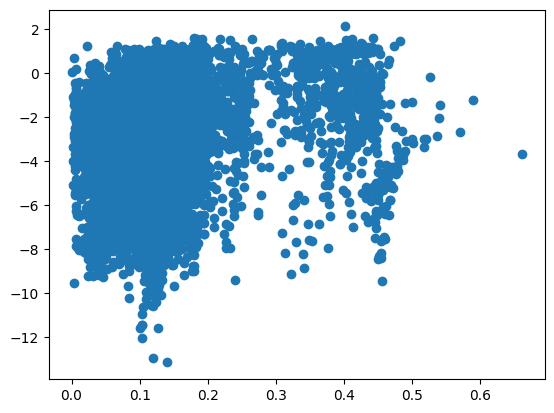

In [14]:
plt.scatter(df["homo_lumo_gap"], df["solubility"])

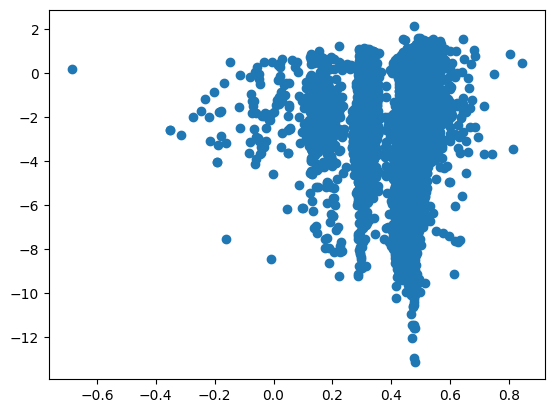

In [15]:
plt.scatter(df["ionization_energy"], df["solubility"])

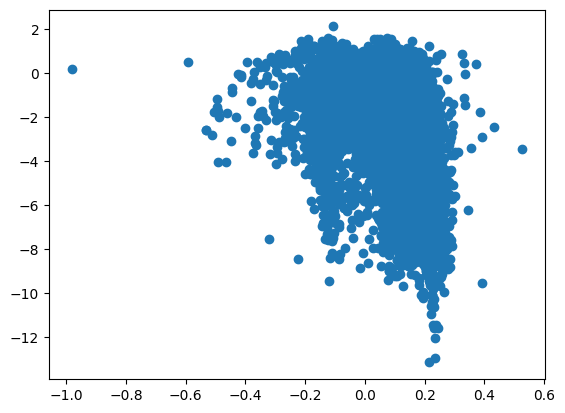

In [16]:
plt.scatter(df["electron_affinity"], df["solubility"])

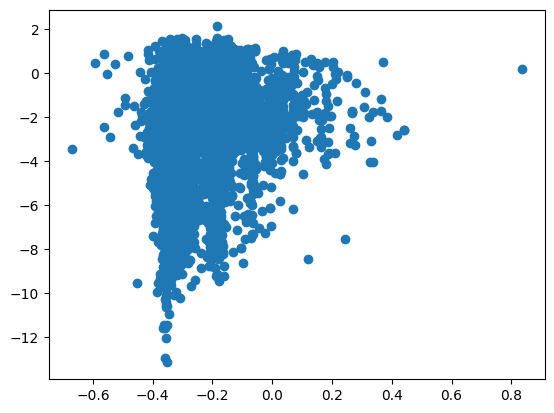

In [17]:
plt.scatter(df["chemical_potential"], df["solubility"])

<Axes: xlabel='HeavyAtomCount', ylabel='homo_lumo_gap'>

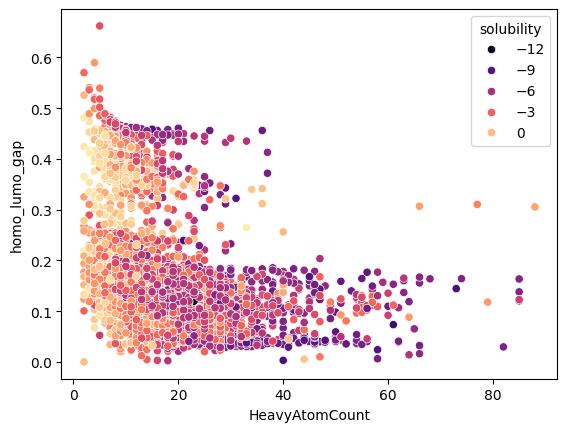

In [32]:
sns.scatterplot(data=df, x="HeavyAtomCount", y="homo_lumo_gap", hue="solubility", palette="magma")

<Axes: xlabel='electron_affinity', ylabel='ionization_energy'>

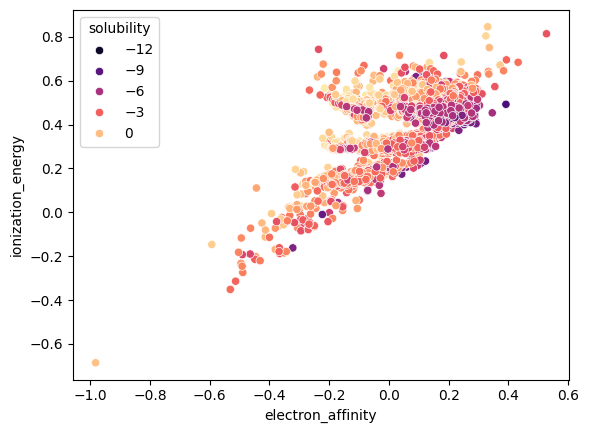

In [19]:
sns.scatterplot(data=df, x="electron_affinity", y="ionization_energy", hue="solubility", palette="magma")

<Axes: xlabel='TPSA_per_atom', ylabel='solubility'>

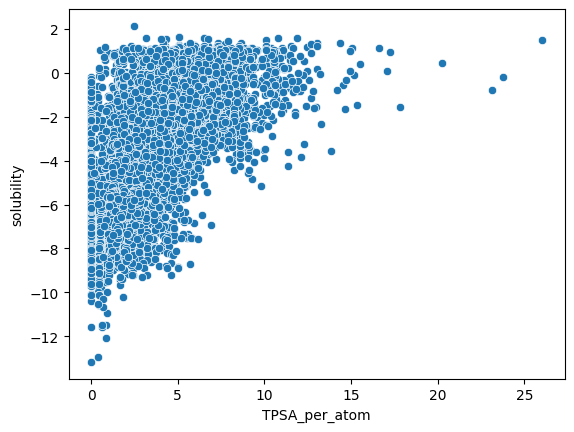

In [65]:
# sns.scatterplot(data=df, x="n_atoms", y="TPSA_per_atom", hue="solubility", palette="magma")
sns.scatterplot(data=df, x="TPSA_per_atom", y="solubility")

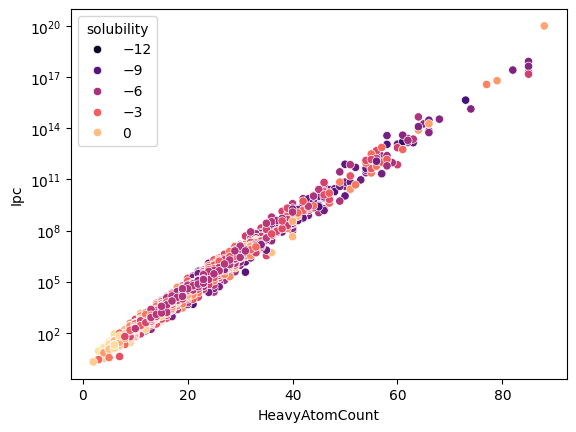

In [39]:
sns.scatterplot(data=df, x="HeavyAtomCount", y="Ipc", hue="solubility", palette="magma")
# plt.xscale("log")
plt.yscale("log")

In [22]:
df["avg_atomic_quadrupole_principal_invariant_2"].describe()

count    8763.000000
mean       -0.068586
std         0.096430
min        -7.786854
25%        -0.083618
50%        -0.060912
75%        -0.041231
max        -0.000108
Name: avg_atomic_quadrupole_principal_invariant_2, dtype: float64

In [42]:
df["abs_molecular_quadrupole_principal_invariant_2"] = abs(df["molecular_quadrupole_principal_invariant_2"])
df["abs_molecular_quadrupole_principal_invariant_3"] = abs(df["molecular_quadrupole_principal_invariant_3"])

C:\Users\thibo\AppData\Local\Temp\ipykernel_19124\1145970829.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["abs_molecular_quadrupole_principal_invariant_2"] = abs(df["molecular_quadrupole_principal_invariant_2"])
C:\Users\thibo\AppData\Local\Temp\ipykernel_19124\1145970829.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["abs_molecular_quadrupole_principal_invariant_3"] = abs(df["molecular_quadrupole_principal_invariant_3"])


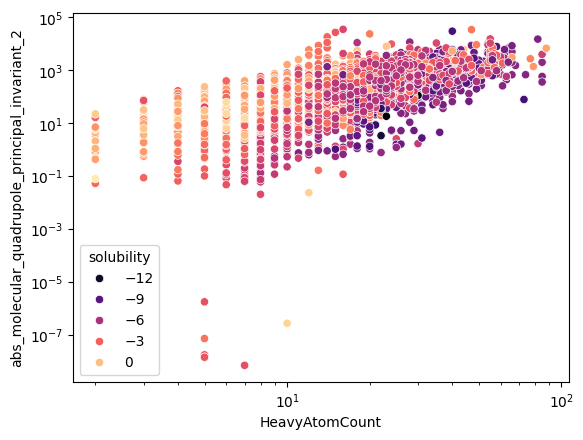

In [43]:
sns.scatterplot(data=df, x="HeavyAtomCount", y="abs_molecular_quadrupole_principal_invariant_2", hue="solubility", palette="magma")
plt.xscale("log")
plt.yscale("log")

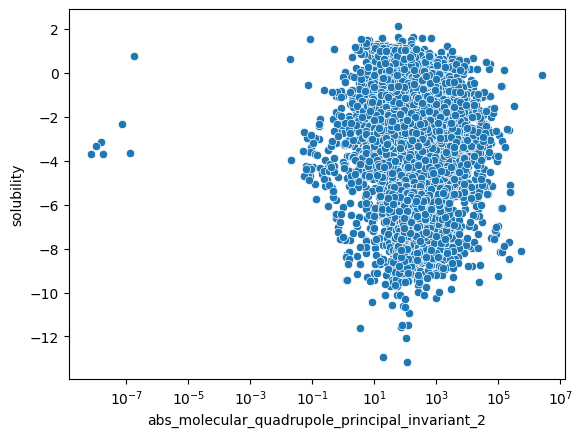

In [25]:
sns.scatterplot(data=df, x="abs_molecular_quadrupole_principal_invariant_2", y="solubility")
plt.xscale("log")
# plt.yscale("log")

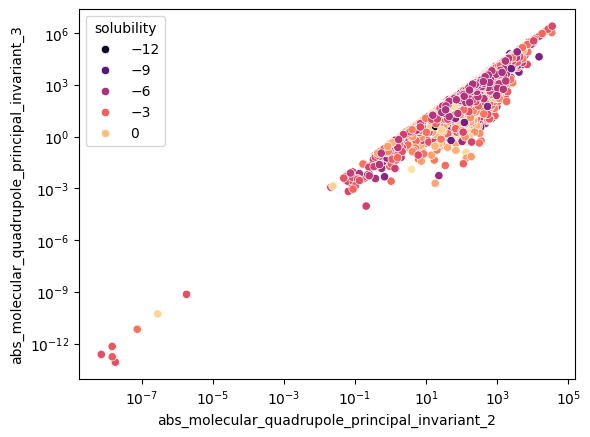

In [44]:
sns.scatterplot(data=df, x="abs_molecular_quadrupole_principal_invariant_2", y="abs_molecular_quadrupole_principal_invariant_3", hue="solubility", palette="magma")
plt.xscale("log")
plt.yscale("log")

In [27]:
df["abs_min_atomic_quadrupole_principal_invariant_2"] = abs(df["min_atomic_quadrupole_principal_invariant_2"])
df["abs_max_atomic_quadrupole_principal_invariant_2"] = abs(df["max_atomic_quadrupole_principal_invariant_2"])
df["abs_std_atomic_quadrupole_principal_invariant_2"] = abs(df["std_atomic_quadrupole_principal_invariant_2"])
df["abs_min_atomic_quadrupole_principal_invariant_3"] = abs(df["min_atomic_quadrupole_principal_invariant_3"])
df["abs_max_atomic_quadrupole_principal_invariant_3"] = abs(df["max_atomic_quadrupole_principal_invariant_3"])
df["abs_std_atomic_quadrupole_principal_invariant_3"] = abs(df["std_atomic_quadrupole_principal_invariant_3"])

C:\Users\thibo\AppData\Local\Temp\ipykernel_16108\2959661098.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["abs_min_atomic_quadrupole_principal_invariant_2"] = abs(df["min_atomic_quadrupole_principal_invariant_2"])
C:\Users\thibo\AppData\Local\Temp\ipykernel_16108\2959661098.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["abs_max_atomic_quadrupole_principal_invariant_2"] = abs(df["max_atomic_quadrupole_principal_invariant_2"])
C:\Users\thibo\AppData\Local\Temp\ipykernel_16108\2959661098.py:3: PerformanceWarning:

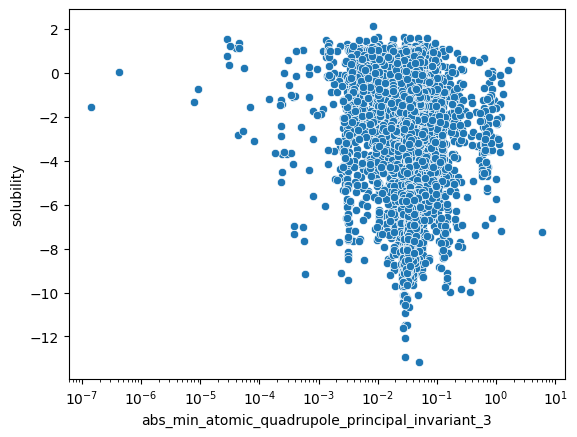

In [28]:
sns.scatterplot(data=df, x="abs_min_atomic_quadrupole_principal_invariant_3", y="solubility")
plt.xscale("log")
# plt.yscale("log")

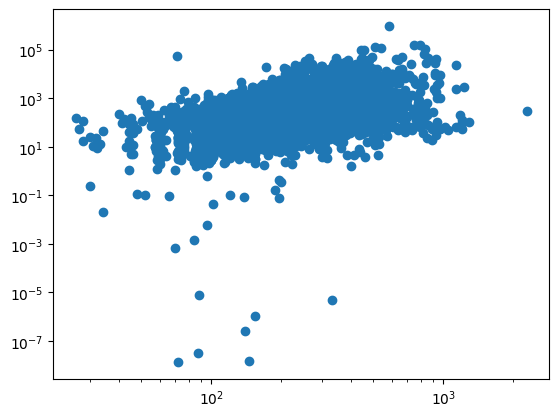

In [55]:
plt.scatter(df["MolWt"], df["molecular_polarizability_anisotropy"] / df["num_atoms"])
plt.xscale("log")
plt.yscale("log")

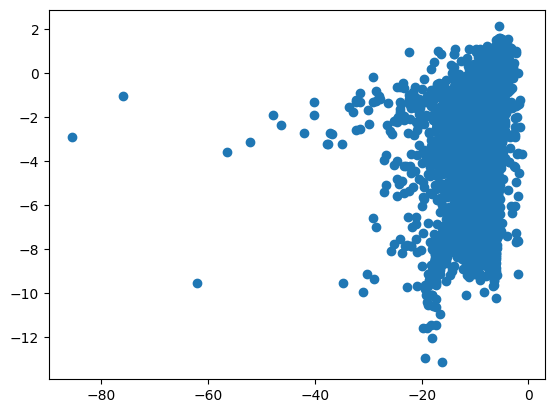

In [30]:
plt.scatter(df["molecular_polarizability_mean"] / df["num_atoms"], df["solubility"])

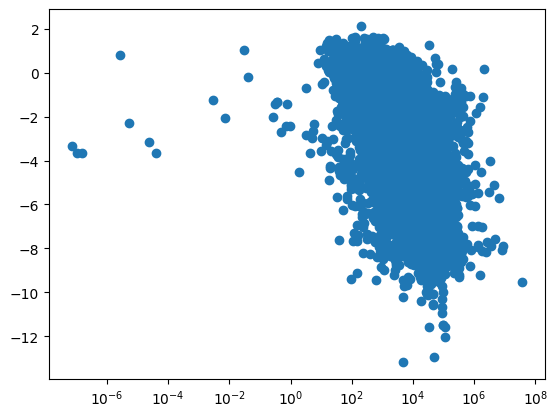

In [31]:
plt.scatter(df["molecular_polarizability_anisotropy"], df["solubility"])
plt.xscale("log")

(-1.0, 5.0)

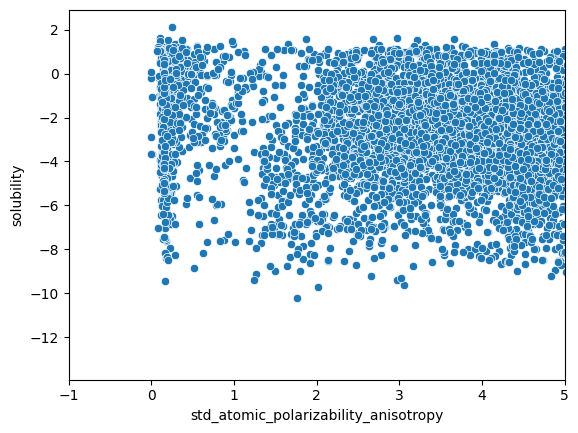

In [32]:
sns.scatterplot(data=df, x=df["std_atomic_polarizability_anisotropy"].abs(), y="solubility")
# plt.xscale("log")
plt.xlim(-1, 5)
# # plt.yscale("log")

In [33]:
df["max_atomic_dipole_norm"].describe()

count    8763.000000
mean        0.299506
std         0.135549
min         0.004489
25%         0.241458
50%         0.275002
75%         0.301966
max         1.607833
Name: max_atomic_dipole_norm, dtype: float64

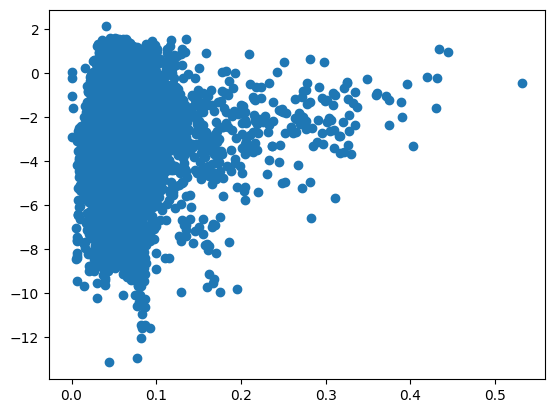

In [34]:
plt.scatter(df["std_atomic_dipole_norm"], df["solubility"])

<Axes: xlabel='max_atomic_dipole_norm', ylabel='std_atomic_dipole_norm'>

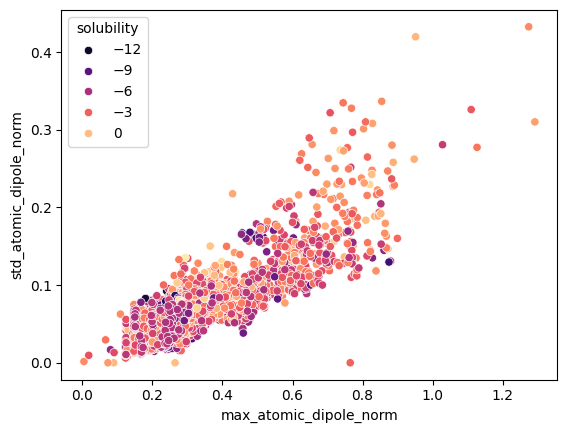

In [46]:
sns.scatterplot(data=df, x="max_atomic_dipole_norm", y="std_atomic_dipole_norm", hue="solubility", palette="magma")
# plt.xscale("log")
# plt.yscale("log")

<Axes: xlabel='molecular_polarizability_mean', ylabel='molecular_polarizability_anisotropy'>

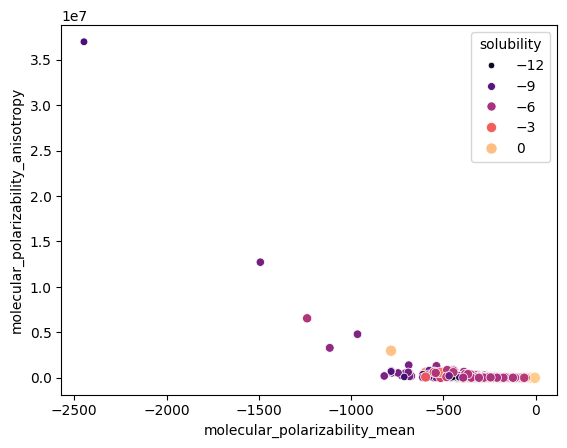

In [49]:
sns.scatterplot(data=df, x="molecular_polarizability_mean", y="molecular_polarizability_anisotropy", hue="solubility", size="solubility", palette="magma")
# plt.yscale("log")

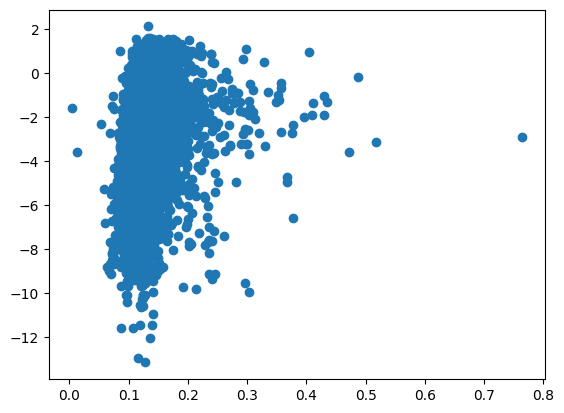

In [38]:
plt.scatter(df["avg_atomic_dipole_norm"], df["solubility"])

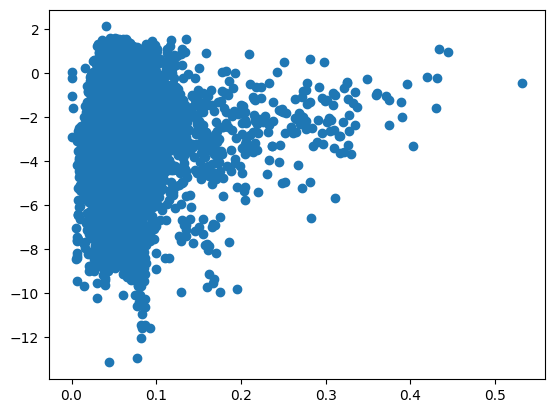

In [39]:
plt.scatter(df["std_atomic_dipole_norm"], df["solubility"])

<Axes: xlabel='std_partial_charge', ylabel='solubility'>

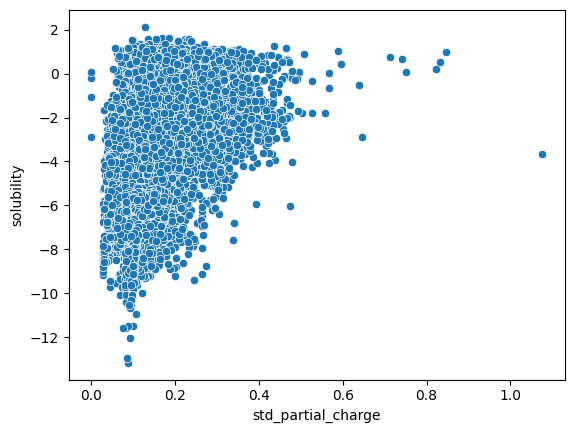

In [40]:
sns.scatterplot(data=df, x="std_partial_charge", y="solubility")

<Axes: xlabel='std_partial_charge', ylabel='PEOE_VSA6'>

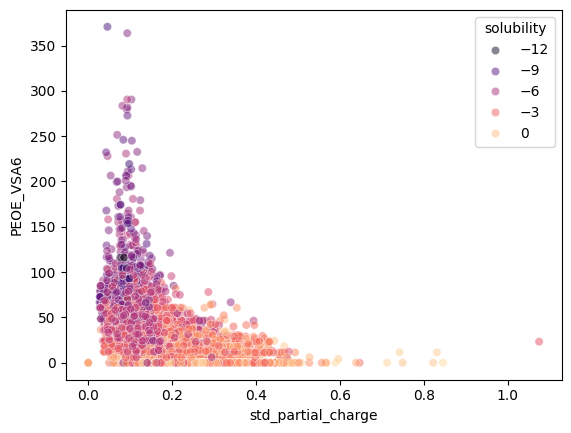

In [41]:
sns.scatterplot(data=df, x="std_partial_charge", y="PEOE_VSA6", hue="solubility", palette="magma", alpha=0.5)

<Axes: xlabel='max_bond_length', ylabel='max_bond_stiffness'>

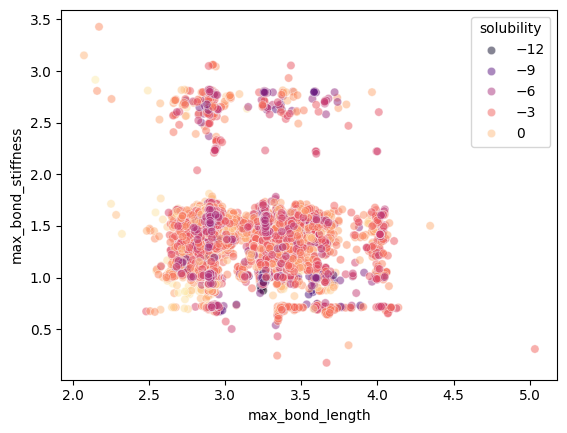

In [42]:
sns.scatterplot(data=df, x="max_bond_length", y="max_bond_stiffness", hue="solubility", palette="magma", alpha=0.5)

(-1.0, 20.0)

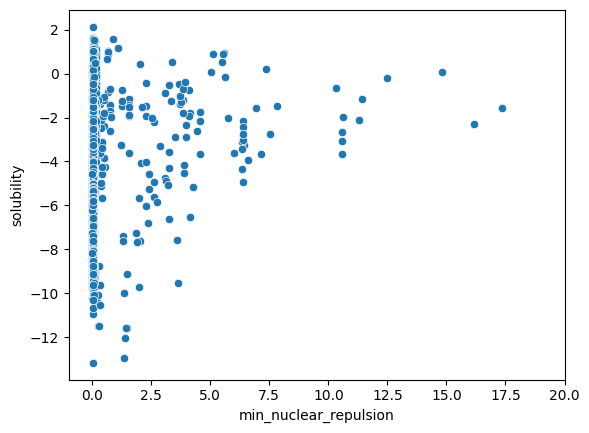

In [44]:
sns.scatterplot(data=df, x="min_nuclear_repulsion", y="solubility")
# plt.xscale("log")
plt.xlim(-1, 20)

<Axes: xlabel='min_partial_charge', ylabel='solubility'>

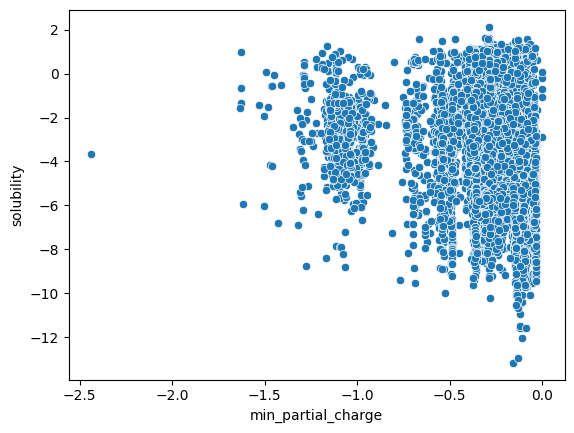

In [47]:
sns.scatterplot(data=df, x="min_partial_charge", y="solubility")

<Axes: xlabel='MolWt', ylabel='heat_capacity_300K_range'>

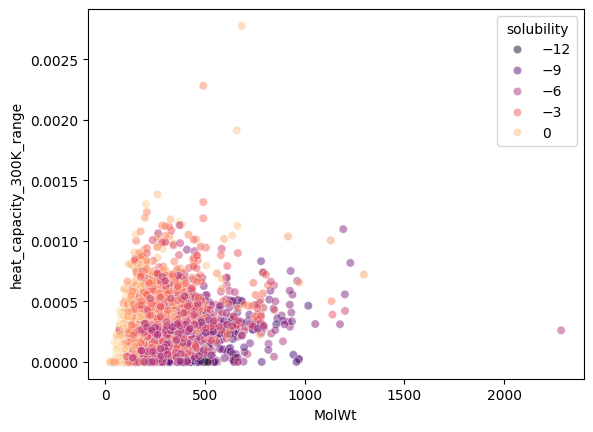

In [48]:
sns.scatterplot(data=df, x="MolWt", y="heat_capacity_300K_range", hue="solubility", palette="magma", alpha=0.5)
# plt.xscale("log")
# plt.yscale("log")

<Axes: xlabel='HeavyAtomCount', ylabel='NumRadicalElectrons'>

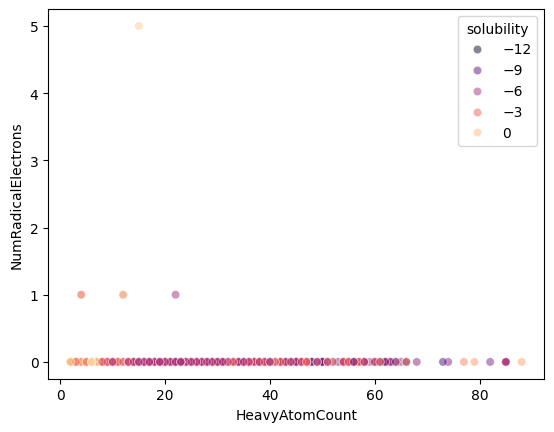

In [50]:
sns.scatterplot(data=df, x="HeavyAtomCount", y="NumRadicalElectrons", hue="solubility", palette="magma", alpha=0.5)
# plt.xscale("log")
# plt.yscale("log")

<Axes: xlabel='HeavyAtomCount', ylabel='EState_VSA4'>

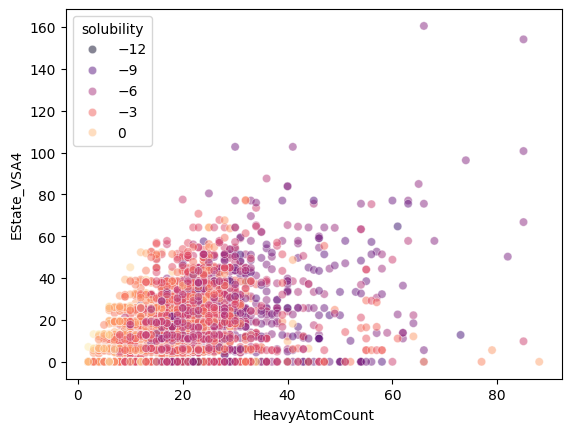

In [51]:
sns.scatterplot(data=df, x="HeavyAtomCount", y="EState_VSA4", hue="solubility", palette="magma", alpha=0.5)
# plt.yscale("log")

<Axes: xlabel='HeavyAtomCount', ylabel='radius_of_gyration'>

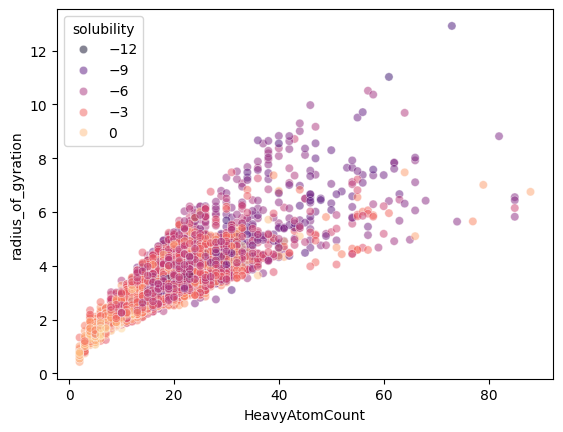

In [53]:
# sns.scatterplot(data=df, x="HeavyAtomCount", y=(df["radius_of_gyration"])**1.75, hue="solubility", palette="magma", alpha=0.5)
sns.scatterplot(data=df, x="HeavyAtomCount", y="radius_of_gyration", hue="solubility", palette="magma", alpha=0.5)
# plt.yscale("log")

<Axes: xlabel='TPSA', ylabel='NumHAcceptors'>

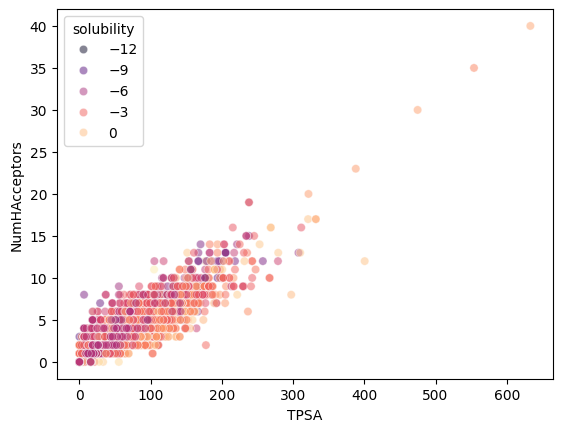

In [55]:
sns.scatterplot(data=df, x="TPSA", y="NumHAcceptors", hue="solubility", palette="magma", alpha=0.5)
# plt.yscale("log")

There seem to be quite a lot of features that correlate perfectly with each other (Pearson correlation of 1). There also seem to be some features that essentially say the same thing, like MolWt and ExactMolWt. As they serve no purpose besides increasing the amount of dimensions of our data, we can remove them. 

<Axes: >

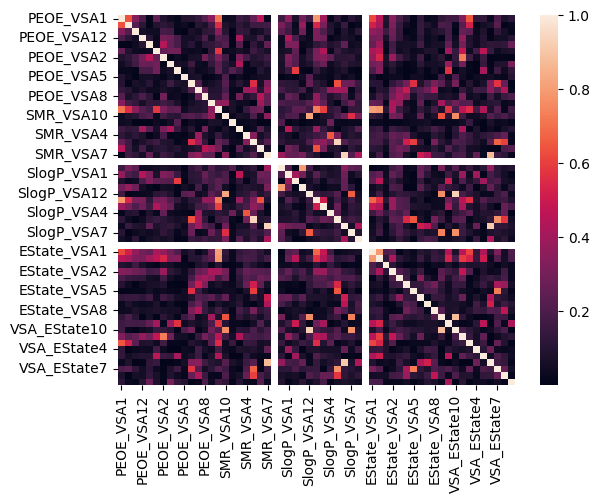

In [406]:
sns.heatmap(df.filter(regex="VSA").corr().abs())

In [12]:
energy_corr = X_filtered.corr()["std_nuclear_repulsion"].sort_values()
energy_corr.abs().sort_values(ascending=False).head(50)

std_nuclear_repulsion                          1.000000
std_atomic_polarizability_anisotropy           0.855196
max_nuclear_repulsion                          0.807849
std_atomic_polarizability_mean                 0.722240
avg_atomic_polarizability_mean                 0.714797
std_atomic_sasa                                0.690729
avg_atomic_sasa                                0.654627
std_atomic_dipole_norm                         0.631460
avg_bond_length                                0.603376
BCUT2D_MWHI                                    0.603350
avg_atomic_dipole_norm                         0.576067
min_atomic_polarizability_mean                 0.550414
std_bond_length                                0.531530
BCUT2D_MRHI                                    0.510461
avg_nuclear_repulsion                          0.507197
SlogP_VSA12                                    0.497661
max_atomic_sasa                                0.485634
std_atomic_fukui_plus                          0

In [13]:
energy_corr = X_filtered.corr()["molecular_dipole_norm"].sort_values()
energy_corr.abs().sort_values(ascending=False).head(25)

molecular_dipole_norm             1.000000
max_partial_charge_water          0.544464
max_partial_charge_dmso           0.544431
max_partial_charge_thf            0.544084
max_partial_charge_cyclohexane    0.542912
max_partial_charge                0.538855
ionization_energy                 0.536039
gibbs_free_energy_300K_range      0.472394
enthalpy_range                    0.472093
std_enthalpy                      0.467573
std_energy                        0.458179
std_gibbs_free_energy_300K        0.457511
chemical_potential                0.426795
energy_range                      0.420067
delta_energy                      0.418730
TPSA                              0.410217
fr_COO                            0.398616
fr_COO2                           0.398041
MinAbsPartialCharge               0.388716
heat_capacity_300K_range          0.380217
homo_lumo_gap                     0.378582
std_heat_capacity_300K            0.375965
MaxEStateIndex                    0.373766
MaxAbsEStat

Index(['delta_entropy_300K', 'entropy_300K_range', 'std_entropy_300K',
       'delta_heat_capacity_300K', 'heat_capacity_300K_range',
       'std_heat_capacity_300K', 'std_bond_energy', 'min_overlap_integral',
       'avg_atomic_charge_dipole_interaction',
       'std_atomic_charge_dipole_interaction',
       'avg_atomic_charge_quadrupole_interaction',
       'std_atomic_charge_quadrupole_interaction',
       'avg_atomic_dipole_dipole_interaction',
       'std_atomic_dipole_dipole_interaction', 'SMR_VSA8', 'SlogP_VSA9'],
      dtype='str')


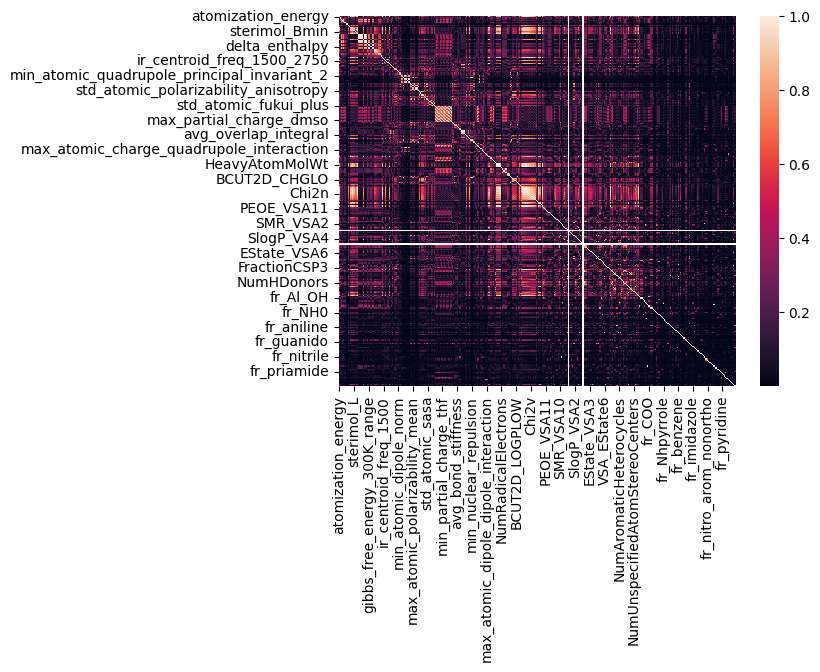

In [14]:
corr = X.corr().abs()

sns.heatmap(corr)
print(X.columns[X.std() < 0.01])

The Pearson correlation plot reveals there are two features that correlate with 0 other features: `"SMR_VSA8"` and `"SlogP_SVA9"`. This is because these features are constant. They can be removed as they provide zero information to the model.

In [15]:
corr_target = X_filtered.corrwith(y).abs().sort_values(ascending=True)
# corr_target.filter(regex="dipole")
corr_target[corr_target < 0.01]

c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


PEOE_VSA12                                     0.000071
max_atomic_quadrupole_principal_invariant_2    0.000200
BCUT2D_LOGPLOW                                 0.000248
NumRadicalElectrons                            0.000383
fr_C_S                                         0.000895
fr_Nhpyrrole                                   0.001402
fr_Ar_NH                                       0.001402
fr_sulfide                                     0.002132
max_bond_stiffness                             0.002335
fr_Ndealkylation2                              0.002371
avg_atomic_polarizability_anisotropy           0.002432
fr_diazo                                       0.002698
avg_atomic_quadrupole_principal_invariant_3    0.003157
NumBridgeheadAtoms                             0.003633
max_atomic_polarizability_mean                 0.003685
ir_norm_intensity_2750_4000                    0.003714
VSA_EState9                                    0.003738
std_atomic_quadrupole_principal_invariant_3    0

In [350]:
corr_target.filter(regex="_range")

heat_capacity_300K_range        0.041425
gibbs_free_energy_300K_range    0.099509
energy_range                    0.108539
entropy_300K_range              0.134580
enthalpy_range                  0.142101
dtype: float64

In [496]:
size_ref = "num_atoms"

corr_with_size = X.corr(numeric_only=True)[size_ref].sort_values(ascending=False)

# put into dataframe
corr_df = corr_with_size.reset_index()
corr_df.columns = ["feature", "corr_with_MolWt"]

# absolute correlation (more useful)
corr_df["abs_corr"] = corr_df["corr_with_MolWt"].abs()

# sort by strength
corr_df = corr_df.sort_values("abs_corr", ascending=False)
corr_df = corr_df.set_index("feature")

corr_df.filter(regex="molecular_sasa", axis=0)

,corr_with_MolWt,abs_corr
feature,,
molecular_sasa,0.962972,0.962972


In [18]:
size_features = ["MolWt", "HeavyAtomCount", "molecular_volume", "molecular_sasa"]

corr_multi = X.corr(numeric_only=True)[size_features].abs()
# condition = corr_multi["MolWt"] > 0.9 and corr_multi["HeavyAtomCount"] > 0.9 and corr_multi["molecular_volume"] > 0.9 and corr_multi["molecular_sasa"] > 0.9

corr_multi[corr_multi > 0.9].dropna()

,MolWt,HeavyAtomCount,molecular_volume,molecular_sasa
molecular_volume,0.927660,0.969472,1.000000,0.993700
molecular_sasa,0.930994,0.962972,0.993700,1.000000
MolWt,1.000000,0.947989,0.927660,0.930994
ExactMolWt,0.999987,0.949171,0.928801,0.932009
NumValenceElectrons,0.945449,0.991316,0.985521,0.979360
Chi0,0.952424,0.996527,0.972498,0.967829
Chi0n,0.900872,0.973717,0.991689,0.979088
Chi0v,0.964474,0.968143,0.988101,0.982773
Chi1,0.941479,0.998586,0.969361,0.963680
Chi1v,0.930013,0.936623,0.971426,0.963924


In [19]:
from ml_enhance import get_topology_features

topo_features = get_topology_features()
qm_df = X.drop(topo_features, axis=1)
qm_features = qm_df.columns

In [20]:
# corr_mw = corr_with_size[corr_with_size["feature"] == "MolMR"]["corr_with_MolWt"]
corr_with_size["MolMR"]

np.float64(0.9474600427769536)

In [500]:
from pingouin import partial_corr

results = []


X_t = X.drop(["MolWt", "ExactMolWt", "HeavyAtomMolWt"], axis=1)
corr = qm_df.corrwith(y)

for f in qm_df.columns:
    pc = partial_corr(data=df, x=f, y="solubility", covar="MolWt")
    r = corr[f]
    corr_mw = corr_with_size[f]
    results.append((f, corr_mw, abs(corr_mw), r, abs(r), pc["r"].values[0], abs(pc["r"].values[0]), pc["p_val"].values[0]))

pc_df = pd.DataFrame(results, columns=["feature", "corr_with_MolWt", "abs_corr_with_MolWt", "r", "abs_r", "partial_r", "abs_partial_r", "p"])

In [502]:
test = pc_df.set_index("feature")
test.filter(regex="molecular_sasa", axis=0).sort_values("abs_corr_with_MolWt", ascending=False)

,corr_with_MolWt,abs_corr_with_MolWt,r,abs_r,partial_r,abs_partial_r,p
feature,,,,,,,
molecular_sasa,0.962972,0.962972,-0.564594,0.564594,-0.04181,0.04181,0.00009


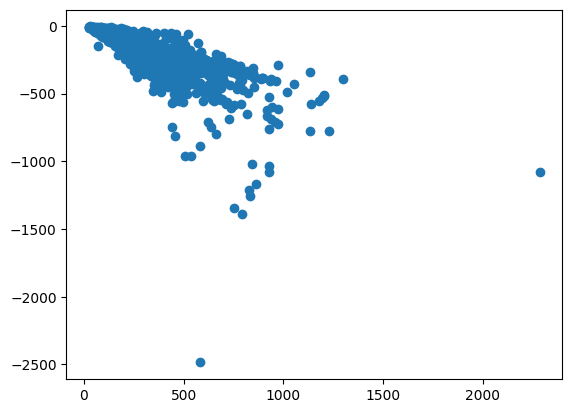

In [23]:
# plt.scatter(df['MolWt'], df["molecular_dipole_norm"])
# plt.scatter(df['MolWt'], df["molecular_polarizability_anisotropy"])
plt.scatter(df['MolWt'], df['molecular_polarizability_mean'])
# plt.yscale("log")
# plt.ylim(-5, 100)

In [24]:
pc_df.sort_values("abs_corr_with_MolWt", ascending=False).head(50) # [pc_df["feature"].str.contains("dipole")]

,feature,corr_with_MolWt,abs_corr_with_MolWt,r,abs_r,partial_r,abs_partial_r,p
16,molecular_sasa,0.930994,0.930994,-0.564594,0.564594,-0.041810,0.041810,9.046992e-05
12,molecular_volume,0.927660,0.927660,-0.552814,0.552814,-0.008263,0.008263,4.393047e-01
0,atomization_energy,0.863184,0.863184,-0.474596,0.474596,0.092221,0.092221,5.168618e-18
38,ir_mode_count_1500,0.858131,0.858131,-0.467962,0.467962,0.099486,0.099486,1.017168e-20
11,radius_of_gyration,0.831624,0.831624,-0.587626,0.587626,-0.210865,0.210865,1.224313e-88
8,molecular_polarizability_mean,-0.824367,0.824367,0.633783,0.633783,0.317612,0.317612,1.430063e-204
13,sterimol_L,0.805289,0.805289,-0.578522,0.578522,-0.211171,0.211171,6.759307e-89
115,std_overlap_integral,-0.795602,0.795602,0.554250,0.554250,0.168676,0.168676,6.252590e-57
15,sterimol_Bmax,0.771945,0.771945,-0.478342,0.478342,-0.039842,0.039842,1.911626e-04
10,zero_point_energy,0.732870,0.732870,-0.398370,0.398370,0.066462,0.066462,4.748094e-10


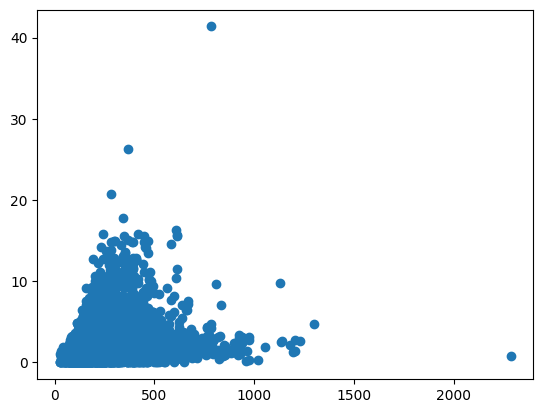

In [25]:
# plt.scatter(df["MolWt"], np.log(df["Ipc"]))
plt.scatter(df["MolWt"], df["molecular_dipole_norm"])
# plt.yscale("log")

In [26]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

def partial_corr_all(df, y, features, target, covars):
    results = []

    # ensure clean data
    # data = df[features + [target] + covars].dropna()
    data = df

    corr_y = df.corrwith(y)

    X_cov = data[covars].values
    y = data[target].values

    # residualize target once
    y_res = y - LinearRegression().fit(X_cov, y).predict(X_cov)

    for f in features:
        try:
            x = data[f].values

            # skip constant features
            if np.std(x) == 0:
                continue

            # residualize feature
            x_res = x - LinearRegression().fit(X_cov, x).predict(X_cov)

            # correlation = partial correlation
            r = np.corrcoef(x_res, y_res)[0, 1]

            results.append({
                "feature": f,
                "corr_with_MolWt": corr_with_size[f],
                "abs_corr_with_MolWt": abs(corr_with_size[f]),
                "r": corr_y[f],
                "abs_r": abs(corr_y[f]),
                "partial_r": r,
                "abs_partial_r": abs(r)
            })

        except Exception:
            print(f"exception, {f}")
            continue

    return pd.DataFrame(results)

target = "solubility"

covars = ["MolWt"]   # or better: size_PC1 later

t_df = df.drop(["smiles", "canon_smiles", "id"], axis=1)

features = [c for c in t_df.columns if c != target]

pc_df = partial_corr_all(t_df, y, features, target, covars)

pc_df = pc_df.sort_values("abs_partial_r", ascending=False)

c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [27]:
pc_df[pc_df["feature"] == "avg_nuclear_repulsion"]

,feature,corr_with_MolWt,abs_corr_with_MolWt,r,abs_r,partial_r,abs_partial_r
116,avg_nuclear_repulsion,-0.007739,0.007739,-0.006363,0.006363,-0.013608,0.013608


In [28]:
pc_df.sort_values("abs_corr_with_MolWt", ascending=False).head(50)

,feature,corr_with_MolWt,abs_corr_with_MolWt,r,abs_r,partial_r,abs_partial_r
139,MolWt,1.000000,1.000000,-0.593245,0.593245,0.003536,0.003536
141,ExactMolWt,0.999987,0.999987,-0.591988,0.591988,0.309083,0.309083
140,HeavyAtomMolWt,0.997239,0.997239,-0.597023,0.597023,-0.090606,0.090606
179,LabuteASA,0.974490,0.974490,-0.602365,0.602365,-0.134241,0.134241
164,Chi0v,0.964474,0.964474,-0.593217,0.593217,-0.098970,0.098970
162,Chi0,0.952424,0.952424,-0.537676,0.537676,0.111451,0.111451
237,HeavyAtomCount,0.947989,0.947989,-0.551273,0.551273,0.043384,0.043384
262,MolMR,0.947460,0.947460,-0.618193,0.618193,-0.217924,0.217924
142,NumValenceElectrons,0.945449,0.945449,-0.521809,0.521809,0.148993,0.148993
165,Chi1,0.941479,0.941479,-0.555118,0.555118,0.012564,0.012564


In [29]:
from pingouin import partial_corr
import pandas as pd

def compute_partial_corr_all(df, target, covar, exclude=None):
    if exclude is None:
        exclude = [target]
    
    features = [c for c in df.columns if c not in exclude]

    results = []

    for f in features:
        try:
            pc = partial_corr(
                data=df,
                x=f,
                y=target,
                covar=covar
            )

            results.append({
                "feature": f,
                "partial_r": pc["r"].values[0],
                "p_value": pc["p-val"].values[0]
            })

        except Exception:
            continue

    return pd.DataFrame(results)

In [30]:
pc_df = compute_partial_corr_all(
    df=t_df,
    target="solubility",
    covar="MolWt"
)

pc_df

""


In [31]:
from ml_enhance import load_hpc_result
from pathlib import Path

BASE = Path("../data/HuberReg_results")

combo_df = load_hpc_result(BASE / "HuberReg_combo_results.pkl", "topo+QM")
combo_filtered_df = load_hpc_result(BASE / "HuberReg_combo_filtered_results.pkl", "topo+QM_filtered")

In [32]:
model = combo_df["estimator"].values[0].best_estimator_
model_features = model[:-1].get_feature_names_out()
df_features = X.columns
filtered_out = [feature for feature in df_features if feature not in model_features]
filtered_out

['molecular_quadrupole_principal_invariant_3',
 'zero_point_energy',
 'molecular_volume',
 'sterimol_L',
 'molecular_sasa',
 'solvation_energy_thf',
 'solvation_energy_cyclohexane',
 'solvation_energy_dmso',
 'gibbs_free_energy_300K',
 'delta_energy',
 'energy_range',
 'std_energy',
 'std_gibbs_free_energy_300K',
 'enthalpy_range',
 'std_enthalpy',
 'ir_mode_count_1500',
 'ir_mode_count_2750_4000',
 'avg_atomic_quadrupole_principal_invariant_3',
 'max_atomic_quadrupole_principal_invariant_3',
 'min_atomic_polarizability_anisotropy',
 'max_atomic_polarizability_anisotropy',
 'min_partial_charge_water',
 'max_partial_charge_water',
 'std_partial_charge_water',
 'min_partial_charge_thf',
 'max_partial_charge_thf',
 'std_partial_charge_thf',
 'min_partial_charge_cyclohexane',
 'max_partial_charge_cyclohexane',
 'std_partial_charge_cyclohexane',
 'min_partial_charge_dmso',
 'max_partial_charge_dmso',
 'std_partial_charge_dmso',
 'max_bond_energy',
 'avg_atomic_dipole_dipole_interaction',
 '

In [429]:
X.var().sort_values().head(50)

SMR_VSA8                                           0.000000e+00
SlogP_VSA9                                         0.000000e+00
std_heat_capacity_300K                             4.686702e-09
delta_heat_capacity_300K                           1.630806e-08
heat_capacity_300K_range                           3.780323e-08
avg_atomic_charge_dipole_interaction               4.399101e-07
std_entropy_300K                                   1.110450e-06
avg_atomic_dipole_dipole_interaction               1.988486e-06
avg_atomic_charge_quadrupole_interaction           2.576305e-06
std_atomic_dipole_dipole_interaction               6.734183e-06
delta_entropy_300K                                 1.119424e-05
std_atomic_charge_dipole_interaction               1.201717e-05
entropy_300K_range                                 1.552519e-05
std_atomic_charge_quadrupole_interaction           1.626398e-05
std_bond_energy                                    2.180459e-05
min_overlap_integral                    